<a id="top"></a>
# Emerging Technologies Assignment

**Student:** Nora Keavney  
**Student ID:** G00415845

## Overall Explanation for Assignment

This assignment explores how classical and quantum computation approach the same decision problem: determining whether a Boolean function is constant or balanced.

The notebook is structured to build understanding progressively:
- Problem 1 defines and generates valid Boolean functions.
- Problem 2 shows the classical approach and its evaluation cost.
- Problem 3 introduces quantum oracles as reversible function encodings.
- Problem 4 implements Deutsch's algorithm in Qiskit.
- Problem 5 scales the idea to Deutsch-Jozsa for 4-bit inputs.

## Purpose in the Grand Scheme

The broader purpose is to demonstrate early quantum advantage in query complexity.  
Classically, multiple function evaluations are required in the worst case, while Deutsch/Deutsch-Jozsa-type quantum circuits can infer global structure with a single oracle query.

This assignment connects theory, circuit construction, and simulation results to show why quantum algorithms can outperform classical methods for specific promise problems.

## Reference Sections Quick Links
- [Problem 1 References](#ref-problem-1)
- [Problem 2 References](#ref-problem-2)
- [Problem 3 References](#ref-problem-3)
- [Problem 4 References](#ref-problem-4)
- [Problem 5 References](#ref-problem-5)

In [27]:
import itertools
from itertools import product
import random

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## Problem 1: Generating Random Boolean Functions


### Problem Context

This problem creates example Boolean functions that will be used in later parts of the assignment.
The Deutsch–Jozsa algorithm assumes that a function is either constant or balanced, and its goal is to determine which type it is without knowing how the function works internally.

Problem 1 provides these functions in a classical form so they can be tested and analysed in both classical and quantum settings later in the notebook.

---

### Explanation

A Boolean function is a function that maps Boolean inputs to a Boolean output.
In this problem, each function takes **four Boolean inputs**, meaning there are *$2^4 = 16$* possible input combinations.
The function returns a single Boolean value (`True` or `False`) for each of these combinations.

The purpose of this problem is to randomly generate functions that are *guaranteed* to be either constant or balanced.
This mirrors the oracle model used in quantum computing, where the internal behaviour of the function is hidden and only its outputs can be observed through evaluation.

---

### Definitions

**Constant function**  
A Boolean function is constant if it returns the same output for every possible input.
For four input bits, this means the function returns either:
- `False` for all 16 input combinations, or
- `True` for all 16 input combinations.

**Balanced function**  
A Boolean function is balanced if it returns `True` for exactly half of all possible inputs and `False` for the other half.
With four input bits, this corresponds to:
- 8 inputs returning `True`
- 8 inputs returning `False`

---

### Simply Said

In simple terms, this problem creates a hidden Boolean function that:
- takes four `True`/`False` inputs,
- returns a single `True` or `False`,
- and is guaranteed to be either:
  - always the same (constant), or
  - evenly split between `True` and `False` (balanced).

The function type is chosen randomly, and the caller is not told which type was selected.

---

### Importance to Quantum Computing

This distinction between constant and balanced functions is fundamental to the Deutsch–Jozsa algorithm.
Classically, determining whether an unknown Boolean function is constant or balanced may require testing the function on many different inputs.

In contrast, the Deutsch–Jozsa algorithm can determine this global property with a **single evaluation** of the function when implemented as a quantum oracle. In simple terms, quantum computing cares more about the pattern than the inputs.  It can ask the question like *“Are the outputs the same, or do they cancel each other out?”* instead of looping through different inputs to evaluate the outputs.
Problem 1 establishes the classical foundation required to understand this quantum advantage by providing valid functions that satisfy the algorithm’s promise.

By constructing these functions explicitly, we will later compare classical and quantum approaches to solving the same problem.

---
### Example Behaviour

The table below shows the difference between constant and balanced Boolean functions using a small sample of input combinations.
Each input consists of four Boolean values, and the output is a single Boolean value.

| Input (x₁, x₂, x₃, x₄) | Constant Function Output | Balanced Function Output |
|------------------------|--------------------------|--------------------------|
| (False, False, False, False) | True  | False |
| (False, False, False, True)  | True  | True  |
| (False, False, True, False)  | True  | False |
| (False, True, False, False)  | True  | True  |
| (True, False, False, False)  | True  | False |
| (True, True, False, False)   | True  | True  |

In the constant case, the output is the same for every input.
In the balanced case, the outputs are split evenly between `True` and `False` across all possible inputs (only a subset is shown here).

---

### Alternative Approaches Considered

An alternative approach would have been to construct balanced functions using specific logical expressions (e.g., XOR combinations of inputs). While this can produce balanced behaviour, it does not automatically guarantee that exactly half of all 16 inputs return `True` without additional validation logic.

Another possibility would be to generate outputs randomly at each function call. However, this would violate the deterministic “oracle” assumption required by the Deutsch–Jozsa problem, where the function must have fixed behaviour.

For these reasons, a precomputed truth-table approach was selected. This guarantees correctness, and aligns cleanly with the mathematical definition of a Boolean function.

---


In [28]:
def random_constant_balanced():
    """
    Generate a random Boolean function of four Boolean inputs that is guaranteed
    to be either constant or balanced.

    The function takes four Boolean arguments and returns a Boolean.
    The function is randomly chosen to be either:
    
    - constant: always returns True or always returns False
    - balanced: returns True for exactly half of all possible inputs

    """

    # Generate all possible combinations of four Boolean inputs.
    # With four inputs, there are 2^4 = 16 possible combinations.
    inputs = list(itertools.product([False, True], repeat=4))

    # Randomly choose whether the function will be constant or balanced.
    function_type = random.choice(["constant", "balanced"])

    # Dictionary to store the output value for each input combination.
    # This acts as a classical truth table for the function.
    truth_table = {}

    if function_type == "constant":
        # Choose a single Boolean value to return for all inputs.
        value = random.choice([False, True])

        # Assign the same output value to every possible input.
        for inp in inputs:
            truth_table[inp] = value

    else:
        # For a balanced function, exactly half of the outputs must be True.
        # Shuffle the inputs to avoid any structural bias.
        random.shuffle(inputs)

        # Assign True to half of the inputs and False to the remainder.
        half = len(inputs) // 2
        for inp in inputs[:half]:
            truth_table[inp] = True
        for inp in inputs[half:]:
            truth_table[inp] = False

    # Define and return the Boolean function.
    # The function looks up its output from the precomputed truth table.
    def f(x1, x2, x3, x4):
        return truth_table[(x1, x2, x3, x4)]

    return f


In [29]:
# Testing
f = random_constant_balanced()

results = [f(*inp) for inp in itertools.product([False, True], repeat=4)]
print("True outputs:", results.count(True))
print("False outputs:", results.count(False))


True outputs: 16
False outputs: 0


---

<a id="ref-problem-1"></a>
### Problem 1 : References

- [IBM Quantum. *Deutsch-Jozsa Algorithm*.](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)

- [Real Python. *Python Booleans*.](https://realpython.com/python-boolean/)

- [Python Software Foundation. *random : Generate pseudo-random numbers*.](https://docs.python.org/3/library/random.html)

- [Python Software Foundation. *itertools : Functions creating iterators for efficient looping*.](https://docs.python.org/3/library/itertools.html)

[Back to Top](#top)

## Problem 2: Classical Testing for Function Type

### Problem Context

**In Problem 1**, we generated Boolean functions that take four Boolean inputs and return a single Boolean output. Each function was guaranteed to be either **constant** (always returning the same value) or **balanced** (returning `True` for exactly half of the possible inputs).

This problem asks to determine - using a classical algorithm - whether a given function is constant or balanced.

At first glance, this may seem straightforward. However, this question is central to understanding why Deutsch's algorithm was historically significant. Before exploring the quantum solution, one must first understand the *classical cost* of solving the same problem.

The goal here is to understand how many times we must evaluate the function in order to be 100% certain of the answer.

>**What Is a Classical Algorithm?**
A classical algorithm is an algorithm that runs on a traditional (non-quantum) computer. It operates using classical bits, where information is represented as either 0 or 1.
Importantly for this exercise, Inputs are evaluated one at a time.

---

### Conceptual Explanation

To determine whether a function is constant or balanced using a classical computer, we must evaluate the function on specific input combinations and observe the outputs.

The function in this problem takes four Boolean inputs. Since each input can be either `True` or `False`, there are:

$$
2^4 = 16
$$

possible input combinations.

A classical strategy would proceed as follows:

1. Generate all possible input combinations.
2. Evaluate the function on each combination.
3. Record the outputs.
4. Analyze the pattern of the outputs.

If all outputs are identical, the function is **constant**.

If exactly half of the outputs are `True` and half are `False`, the function is **balanced**.

> The **key limitation** of the classical approach is that it must gather information one input at a time. In the worst case, the algorithm may need to evaluate the function on every possible input before it can be completely certain of the result.

---

### Simply Said

We are given a function that takes four `True/False` inputs.  
We know in advance that it is either:

- Always the same (constant), or  
- Half `True` and half `False` (balanced).

To figure out which type it is using a classical computer, we must test the function on different input combinations and observe the outputs.

If every output matches, the function is constant.  
If the outputs are evenly split between `True` and `False`, the function is balanced.

The important question is:  
**How many times do we need to test the function before we can be completely certain?**

---

### Importance to Quantum Computing

This problem highlights the classical cost of determining whether a function is constant or balanced. Under the constant-or-balanced promise, the worst-case deterministic cost is 9 evaluations for 4 inputs; without that promise, checking all 16 inputs is the safest general method. This exponential growth in required evaluations (in general, \(2^n\) for n inputs) becomes impractical as the number of inputs increases. 

Quantum algorithms such as Deutsch’s algorithm demonstrate that this same problem can be solved using only a single query to a quantum oracle. This contrast between classical and quantum query complexity is one of the earliest examples of how quantum computation can offer a theoretical advantage over classical computation.

> **Quantum Oracle** : a theoretical "black box" function used in quantum algorithms to evaluate input data without revealing its inner workings

---

### Example Behaviour

The following examples demonstrate how the classical algorithm evaluates a function
generated in Problem 1 and determines whether it is constant or balanced.

Each call to `determine_constant_balanced` evaluates the function on multiple input
combinations until enough information is gathered to guarantee the correct answer.

For four Boolean inputs there are $$2^4 = 16$$ possible input combinations. In the
worst case under the promise, the classical algorithm needs 9 evaluations to be certain
that the function is constant or balanced. Behaviour

---

### Alternative Approaches Considered

Several alternative approaches could be used to determine whether a function is
constant or balanced.

One option would be to randomly sample inputs rather than testing every possible
combination. This could reduce the number of evaluations in many cases.
However, this approach cannot guarantee a correct answer because a balanced
function might coincidentally return the same value for several sampled inputs.

Another approach would be to stop early once both `True` and `False` outputs
have been observed. In that case the function must be balanced and no further
evaluation is necessary (This trialed below).

The implementation used here guarantees correctness by checking all possible
input combinations if necessary. This ensures that the classification of the
function is always correct.

---

### Efficiency Note (Maximum Calls for Certainty)

For this assignment, the function is promised to be either **constant** or **balanced**.

Under that promise, a deterministic classical algorithm needs at most **9 calls** to be 100% certain:

- If both `True` and `False` are seen, the function is balanced.
- If one value has appeared 9 times, balanced is impossible (balanced allows only 8 of each value), so the function is constant.

Without the promise, the safe general approach is to evaluate all 16 inputs.

### The Code

In [30]:
def determine_constant_balanced(f):
    """
    Classify a promised 4-input Boolean function as constant or balanced.

    Returns:
        "constant" or "balanced"
    """
    result, _ = determine_constant_balanced_with_calls(f)
    return result


def determine_constant_balanced_with_calls(f):
    """
    Classify a promised 4-input Boolean function and report query count.

    Under the constant-or-balanced promise for 4 inputs:
    - best case: 2 calls (observe both True and False)
    - worst case: 9 calls (once one output appears 9 times, balanced is impossible)
    """
    max_true_in_balanced = 8
    max_false_in_balanced = 8

    true_count = 0
    false_count = 0
    call_count = 0

    for inp in itertools.product([False, True], repeat=4):
        value = f(*inp)
        call_count += 1

        if value:
            true_count += 1
        else:
            false_count += 1

        if true_count > 0 and false_count > 0:
            return "balanced", call_count

        if true_count > max_true_in_balanced or false_count > max_false_in_balanced:
            return "constant", call_count

    return "constant", call_count

#### Testing Classical Approach Code

In [31]:
# Testing determine_constant_balanced (required function) and query-count helper

# Example constant function (always returns True)
def constant_example(a, b, c, d):
    return True


# Example balanced function (returns True if sum of inputs is even)
def balanced_example(a, b, c, d):
    return (a + b + c + d) % 2 == 0


print("Constant classification:", determine_constant_balanced(constant_example))
print("Balanced classification:", determine_constant_balanced(balanced_example))

print("Constant (with calls):", determine_constant_balanced_with_calls(constant_example))
print("Balanced (with calls):", determine_constant_balanced_with_calls(balanced_example))

Constant classification: constant
Balanced classification: balanced
Constant (with calls): ('constant', 9)
Balanced (with calls): ('balanced', 2)


### Visualisation of this problem - Truth Table

In [32]:
inputs = list(itertools.product([False, True], repeat=4))

df = pd.DataFrame(inputs, columns=["x1", "x2", "x3", "x4"])
df

df["f(x)"] = [f(*i) for i in inputs]
df

,x1,x2,x3,x4,f(x)
0,False,False,False,False,True
1,False,False,False,True,True
2,False,False,True,False,True
3,False,False,True,True,True
4,False,True,False,False,True
5,False,True,False,True,True
6,False,True,True,False,True
7,False,True,True,True,True
8,True,False,False,False,True
9,True,False,False,True,True


### Classical Limitation

From this we can see that a classical algorithm still relies on repeated evaluations of the function to be certain of its type.

Under the assignment promise (the function is guaranteed constant or balanced), an optimal deterministic strategy needs at most **9 calls** to be 100% certain.

Without that promise, checking all 16 inputs is the safest general method.

This inefficiency motivates quantum algorithms, which use superposition and interference to infer global structure from a single oracle query.

### Refining the Classical Approach

In the previous implementation, the function evaluated all 16 possible input combinations before returning a result. While this guarantees correctness, it does not reflect how a classical algorithm might behave in practice.

If a mismatch between outputs is detected early (for example, if the first call returns `True` and the second returns `False`), we can immediately conclude that the function is balanced. There is no need to continue evaluating the remaining inputs.

To better illustrate this idea, below is a refined version that stops early when sufficient information has been gathered. This allows us to observe both:

- The *best-case* number of function calls (when imbalance is detected quickly), and  
- The *worst-case* number of function calls (when the function is constant).

This refinement makes the classical cost of the problem more explicit.

### The Code

In [33]:
def determine_constant_balanced_early(f):
    """
    Early-stop classifier for promised 4-input Boolean functions.

    Returns:
        ("constant" | "balanced", call_count)
    """
    return determine_constant_balanced_with_calls(f)

#### Testing Refined Classical Approach Code

In [34]:
# Testing the determine_constant_balanced_early function with example functions
# Example constant function
def constant_example(a, b, c, d):
    return True


# Balanced function (will likely trigger early stopping)
def balanced_example(a, b, c, d):
    return (a + b + c + d) % 2 == 0 # % 2 == 0 means it returns True for even sums and False for odd sums, which is balanced.


print("Constant test:", determine_constant_balanced_early(constant_example))
print("Balanced test:", determine_constant_balanced_early(balanced_example))

Constant test: ('constant', 9)
Balanced test: ('balanced', 2)


### Bar Chart Visualisation for Refined Classical Approach

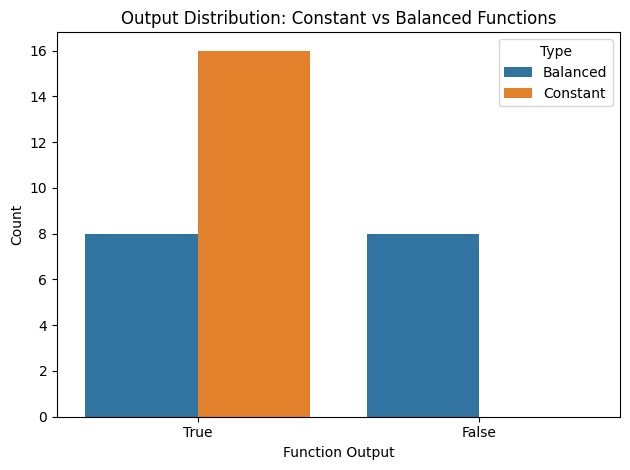

In [35]:
data = pd.DataFrame({
    "Type": ["Balanced", "Balanced", "Constant", "Constant"],
    "Output": ["True", "False", "True", "False"],
    "Count": [8, 8, 16, 0]
})

sns.barplot(data=data, x="Output", y="Count", hue="Type")

plt.title("Output Distribution: Constant vs Balanced Functions")
plt.xlabel("Function Output")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("img/problem2_classical_distribution.png", dpi=300)
plt.show()

### Key Insight

The classical approach relies on evaluating inputs individually and comparing outputs.

This means:
- Information is gathered step by step
- Early stopping is possible, but not guaranteed

This contrasts with quantum computation, where all inputs can be processed in parallel.

---

<a id="ref-problem-2"></a>
### Problem 2 : References
- [IBM Quantum. *Deutsch-Jozsa Algorithm*.](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
- [Deutsch-Josza (sic) problem implementation* : public Kaggle notebook with code and discussion of balanced vs constant function evaluation](https://www.kaggle.com/code/carlolepelaars/q4p-4-deutsch-josza?utm_source=chatgpt.com)
- [Quantum vs Classical: Deutsch & Deutsch-Jozsa Algorithms Explained - Qiskit Youtube Video](https://youtu.be/QcK0GK7DUh8?si=MyOcIHa_kcuK1Wfd)

[Back to Top](#top)

## Problem 3 - Quantum Oracles

### Problem Context

**In Problem 2**, we examined how a classical algorithm determines whether a Boolean function is **constant** or **balanced** by evaluating the function on different input combinations. Because classical algorithms process inputs sequentially, several evaluations may be required before the result can be known with certainty.

In quantum computing, however, functions used inside algorithms are not implemented as ordinary program functions. Instead, they are represented as **quantum oracles**, which are reversible quantum circuits embedded within a larger quantum algorithm.

This problem introduces the oracle representaation used in **Deutsch's algorithm**. For a Boolean function with a single input bit, there are exactly **four possible functions** that map the input to an output. Each of these functions must be implemented as a valid quantum circuit so that it can be used within a quantum computation.

Rather than revealing how the function works internally, the oracle acts as a **black box**. The algorithm can apply the oracle to quantum states and observe the result, but the internal implementation of the function remains hidden.

The goal of this problem is to construct the appropriate **quantum oracle circuits in Qiskit** for each of the four possible single-input Boolean functions used in Deutsch's algorithm and demonstrate how each oracle represents its corresponding function.

> **Quantum Oracle**  
> A quantum oracle is a reversible quantum circuit that encodes a classical function and allows it to be queried within a quantum algorithm.

#### Why Quantum Functions Must Be Reversible

In classical computing, a function takes an input and produces an output, often discarding information in the process. However, in quantum computing, all operations must be **reversible**, meaning the original input must always be recoverable from the output.

To achieve this, quantum functions are implemented as **oracles** that transform both the input and an additional auxiliary bit.

Instead of computing:

    f(x)

quantum oracles compute:

    (x, y) → (x, y ⊕ f(x))

where ⊕ represents XOR.

This ensures that:
- The input x is preserved
- The transformation is reversible
- No information is lost during computation

This structure is essential for implementing quantum algorithms such as Deutsch’s algorithm.

---

### How This Appears in the Circuits

Each oracle circuit implements this transformation:

- If f(x) = 0 → the second qubit remains unchanged  
- If f(x) = 1 → the second qubit is flipped  

For example:
- A NOT gate corresponds to flipping the second qubit
- A CNOT gate applies the function depending on the value of x

This allows the oracle to encode the function while preserving reversibility.

---

### Conceptual Explanation

In the single-input version of Deutsch's problem, the function takes one Boolean input:

$$
x \in \{0,1\}
$$

Because there are only two possible inputs, there are exactly **four possible Boolean functions**:

1. $f(x) = 0$
2. $f(x) = 1$
3. $f(x) = x$
4. $f(x) = \neg x$

These functions fall into two categories:

| Function | Type |
|--------|------|
| $f(x) = 0$ | Constant |
| $f(x) = 1$ | Constant |
| $f(x) = x$ | Balanced |
| $f(x) = \neg x$ | Balanced |

In quantum computing, functions must be implemented in a **reversible form** because all quantum operations must correspond to unitary transformations.

To achieve this, the function is implemented as a **quantum oracle** that acts on two qubits.

> **Qubit**  
> A qubit (quantum bit) is the basic unit of information in quantum computing.  
> Unlike a classical bit, which can only be `0` or `1`, a qubit can exist in a **superposition** (represent multiple possible states 
> simultaneously until it is measured) of both states at the same time.

The oracle applies the transformation:

$$
U_f |x\rangle |y\rangle = |x\rangle |y \oplus f(x)\rangle
$$

where:

- $x$ is the input qubit
- $y$ is an auxiliary qubit
- $\oplus$ represents the XOR operation

This means the oracle **preserves the input qubit** while conditionally flipping the auxiliary qubit depending on the value of the function.

Each of the four Boolean functions can therefore be implemented using combinations of basic quantum gates such as **X gates** and **controlled-NOT (CNOT) gates**.

In the following sections, Qiskit circuits will be constructed to implement each of these four functions as quantum oracles.

---

### Simply Said

In this problem we work with a Boolean function that takes **one input bit**.
Since the input can only be `0` or `1`, there are only **four possible functions**:

- The function always returns `0`
- The function always returns `1`
- The function returns the same value as the input
- The function returns the opposite of the input

In quantum computing, these functions are not written as normal Python functions.  
Instead, they are implemented as **quantum circuits called oracles**.

> **Quantum Circuit**  
> A sequence of quantum gates applied to qubits in order to perform a quantum computation.

- An oracle takes an input qubit and an extra qubit.  
- The oracle may flip the extra qubit depending on the result of the function.
- In this problem we will build four Qiskit circuits, each representing one of these possible functions.
---

### Importance to Quantum Computing

Quantum oracles are an important part of many quantum algorithms.  
They allow a classical function to be used inside a **quantum circuit**.

In classical computing, a function must be tested on different inputs one at a time.  
In quantum computing, the function can be applied to a **superposition** of inputs.

> **Superposition**  
> A quantum state where a qubit can represent multiple possible values at the same time until it is measured.

This idea allows some quantum algorithms to learn information about a function with **fewer evaluations** than a classical algorithm would require. Deutsch’s algorithm is one of the first examples that demonstrates this advantage.


---

### Example Behaviour

Each oracle created in this problem represents one of the four possible Boolean functions.

The oracle takes two qubits as input:

- one qubit representing the **input value**
- one extra qubit used to store the result of the function

When the oracle runs, it checks the value of the input qubit and may flip the second qubit depending on the function.

For example:

- If the function always returns `0`, the second qubit is never changed.
- If the function always returns `1`, the second qubit is always flipped.
- If the function depends on the input value, the second qubit is flipped only for certain inputs.

- The oracle transformation: $$U_f(x, y) = (x, y ⊕ f(x))$$



    can be implemented using simple quantum gates such as NOT and CNOT.

The table below shows how these gates correspond to different functions:

| Gate Used | f(x)          | Input (x, y) | Output (x, y ⊕ f(x)) | Explanation |
|----------|--------------|-------------|----------------------|------------|
| None     | 0            | (x, y)      | (x, y)               | No change, function always returns 0 |
| NOT      | 1            | (x, y)      | (x, y ⊕ 1)           | Second qubit always flipped |
| CNOT     | x            | (x, y)      | (x, y ⊕ x)           | Flip second qubit if x = 1 |
| CNOT + NOT | ¬x         | (x, y)      | (x, y ⊕ ¬x)          | Flip second qubit if x = 0 |

---

### Oracle 1: Constant Function $f(x) = 0$

This oracle represents a function that **always returns 0**, regardless of the input.

Because the function output is always `0`, the oracle does not need to change the output qubit.  
The circuit therefore performs **no operation** on the qubits.

When the oracle is applied, both qubits remain unchanged.

> **Constant Function**  
> A Boolean function that always returns the same output value for every possible input.

This behaviour correctly represents the function $f(x) = 0$.

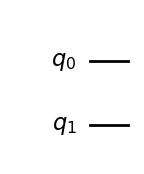

In [36]:
# Oracle for f(x) = 0
# 2 represents 2 Qubits (Input & Auxiliary/Output)
oracle_f0 = QuantumCircuit(2)

# No gates are applied because the function always returns 0

oracle_f0.draw("mpl")

This corresponds to the row in the table where $f(x) = 0$, so no gate is needed and the qubits remain unchanged.

| Gate Used | f(x) | Input (x, y) | Output (x, y ⊕ f(x)) | Explanation |
|----------|------|--------------|------------------------|-------------|
| None     | 0    | (x, y)       | (x, y)                 | No change, function always returns 0 |

### Oracle 2: Constant Function $f(x) = 1$

This oracle represents a function that **always returns 1**, regardless of the input.

Because the function output is always `1`, the oracle must **flip the output qubit every time it is applied**.

This is done using an **X gate** on the second qubit.

> **X Gate**  
> A quantum gate that flips a qubit from `0` to `1` or from `1` to `0`.

When the oracle is applied, the input qubit remains unchanged, and the output qubit is always flipped.

This correctly represents the function $f(x) = 1$.

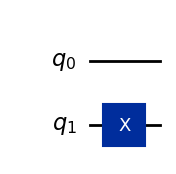

In [37]:
# Create a quantum circuit with 2 qubits:
# q0 -> input qubit (x)
# q1 -> output qubit (y)
oracle_f1 = QuantumCircuit(2, name="f(x)=1")

# Apply an X gate to the output qubit (q1)
# This flips the output regardless of the input value
oracle_f1.x(1)

oracle_f1.draw("mpl")

This corresponds to the row in the table where f(x) = 1, implemented using a NOT gate to flip the second qubit.

| Gate Used | f(x)          | Input (x, y) | Output (x, y ⊕ f(x)) | Explanation |
|----------|--------------|-------------|----------------------|------------|
| NOT      | 1            | (x, y)      | (x, y ⊕ 1)           | Second qubit always flipped |

### Oracle 3: Balanced Function $f(x) = x$

This oracle represents a function where the output is the **same as the input**.

- If the input is `0`, the output is `0`
- If the input is `1`, the output is `1`

Because the output depends on the input, the oracle must **flip the output qubit only when the input qubit is `1`**.

This is achieved using a **Controlled-NOT (CNOT) gate**.

> **Controlled-NOT (CNOT) Gate**  
> A two-qubit gate that flips the target qubit only when the control qubit is `1`.

In this oracle:

- The **input qubit (q0)** acts as the control
- The **output qubit (q1)** acts as the target

This ensures the output qubit is flipped only when the input is `1`, correctly representing the function $f(x) = x$.

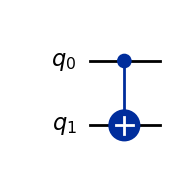

In [38]:
# Create a quantum circuit with 2 qubits:
# q0 -> input qubit (x) [control]
# q1 -> output qubit (y) [target]
oracle_fx = QuantumCircuit(2, name="f(x)=x")

# Apply a CNOT gate:
# If q0 = 1, q1 will be flipped
oracle_fx.cx(0, 1)

oracle_fx.draw("mpl")

This corresponds to the row in the table where f(x) = x, implemented using a CNOT gate with the first qubit as control.

| Gate Used | f(x)          | Input (x, y) | Output (x, y ⊕ f(x)) | Explanation |
|----------|--------------|-------------|----------------------|------------|
| CNOT     | x            | (x, y)      | (x, y ⊕ x)           | Flip second qubit if x = 1 |

### Oracle 4: Balanced Function $f(x) = \neg x$

This oracle represents a function where the output is the **opposite of the input**.

- If the input is `0`, the output is `1`
- If the input is `1`, the output is `0`

The oracle must therefore **flip the output qubit when the input qubit is `0`**, rather than when it is `1`.

Since a CNOT gate only flips the target when the control qubit is `1`, we adjust the input temporarily by applying an **X gate** before and after the CNOT.

> **NOT Gate (X Gate)**  
> A quantum gate that flips a qubit from `0` to `1` or from `1` to `0`.

The steps are:

1. Flip the input qubit  
2. Apply a CNOT gate  
3. Flip the input qubit back  

This makes the output qubit flip only when the original input was `0`, correctly representing the function $f(x) = \neg x$.

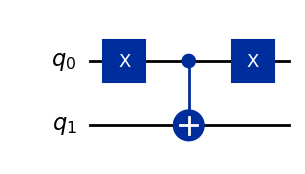

In [39]:
# Create a quantum circuit with 2 qubits:
# q0 -> input qubit (x) [control]
# q1 -> output qubit (y) [target]
oracle_notx = QuantumCircuit(2, name="f(x)=¬x")

# Step 1: Flip the input qubit
oracle_notx.x(0)

# Step 2: Apply CNOT (control = q0, target = q1)
oracle_notx.cx(0, 1)

# Step 3: Flip the input qubit back
oracle_notx.x(0)

oracle_notx.draw("mpl")

This corresponds to the row in the table where f(x) = ¬x, implemented using a combination of NOT and CNOT gates.

| Gate Used | f(x)          | Input (x, y) | Output (x, y ⊕ f(x)) | Explanation |
|----------|--------------|-------------|----------------------|------------|
| CNOT + NOT | ¬x         | (x, y)      | (x, y ⊕ ¬x)          | Flip second qubit if x = 0 |

### Relevance
Unlike the classical approach in Problem 2, where multiple function evaluations may be required, these quantum oracles allow the function to be embedded into a circuit that can later be evaluated in a single step using superposition.

f(x)=0, input=0: {'00': 1024}
f(x)=0, input=1: {'01': 1024}
f(x)=1, input=0: {'10': 1024}
f(x)=1, input=1: {'11': 1024}
f(x)=x, input=0: {'00': 1024}
f(x)=x, input=1: {'11': 1024}
f(x)=¬x, input=0: {'10': 1024}
f(x)=¬x, input=1: {'01': 1024}


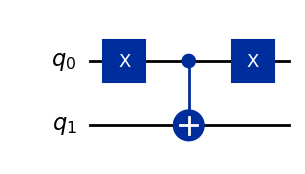

In [40]:
# ALL ORACLES IN ONE PLOT

sim = AerSimulator()

def test_oracle(oracle, name):
    for input_value in [0, 1]:
        qc = QuantumCircuit(2, 2)

        # Set input qubit if x = 1
        if input_value == 1:
            qc.x(0)

        qc.compose(oracle, inplace=True)
        qc.measure([0, 1], [0, 1])

        compiled = transpile(qc, sim)
        result = sim.run(compiled).result()

        counts = result.get_counts()
        print(f"{name}, input={input_value}: {counts}")

# Test all oracles
test_oracle(oracle_f0, "f(x)=0")
test_oracle(oracle_f1, "f(x)=1")
test_oracle(oracle_fx, "f(x)=x")
test_oracle(oracle_notx, "f(x)=¬x")

oracle_f0.draw("mpl")
oracle_f1.draw("mpl")
oracle_fx.draw("mpl")
oracle_notx.draw("mpl")

### Why This Matters

Unlike the classical approach in Problem 2, where multiple evaluations may be required, quantum oracles allow the function to be embedded into a circuit.

When combined with **superposition** and **interference**, this enables Deutsch’s algorithm to determine whether a function is constant or balanced using only a single query.

---

<a id="ref-problem-3"></a>
### Problem 3 : References
- [Discovering a new quantum algorithm - IBM](https://www.ibm.com/quantum/blog/group-theory)
- [What Is Superposition and Why Is It Important? - CalTech](https://scienceexchange.caltech.edu/topics/quantum-science-explained/quantum-superposition)
- [What exactly is an oracle? - Stack Exchange Network](https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626)
- [IBM Quantum. *Qiskit Documentation - Quantum Circuits*](https://qiskit.org/documentation/)
- [Code example: Deutsch-Jozsa algorithm](https://www.quantum-inspire.com/kbase/deutsch-jozsa-algorithm/)
- [Quantum Computing Course: 1.1 Introduction to the Qubit and Superposition - Quantum Soar Youtube Video](https://youtu.be/urNWf4Ezisc?si=BjGlrE8O63p-OQ1P)
- [Quantum Computing Course: 1.2 Introduction to Dirac Notation - Quantum Soar Youtube Video](https://youtu.be/RyPQL8lccx4?si=-HwvTnKyonIic4sh)

[Back to Top](#top)

## Problem 4: Deutsch's Algorithm with Qiskit

### Problem Context

In Problem 3, the four possible single-bit Boolean functions were implemented as quantum oracles.  
In this problem, these oracles are placed inside Deutsch’s algorithm.

The aim is to determine whether the unknown function is **constant** or **balanced** using only **one query** to the oracle.

This is possible because the circuit uses:
- superposition to evaluate both possible inputs at once
- phase kickback to encode the function's behaviour
- interference to reveal whether the function is constant or balanced

--- 

### How Deutsch's Algorithm Works
<img src="img/The-Deutsch-Algorithm.png" width = "700">

Deutsch’s algorithm operates on two qubits:

- The first qubit represents the input
- The second qubit is an auxiliary qubit used by the oracle

The algorithm prepares a superposition of inputs, applies the oracle once, and then uses interference to determine the type of function.

--- 
### Circuit Steps

Deutsch's algorithm follows these steps:

1. Initialise the qubits in the state |0⟩|1⟩  
2. Apply Hadamard gates to both qubits to create superposition  
3. Apply the oracle \( U_f \)  
4. Apply a Hadamard gate to the first qubit  
5. Measure the first qubit  

The measurement result determines whether the function is constant or balanced.

> **Hadamard Gate (H)**:
A Hadamard gate puts a qubit into superposition, meaning it turns a definite state into an equal mix of possibilities.
Simply said:
It takes 0 and makes it “both 0 and 1 at the same time”
It takes 1 and does the same, but with a different phase
---

### Key Quantum Gates Used

> **Hadamard Gate (H):**  
Transforms a qubit into a superposition state.  
|0⟩ → (|0⟩ + |1⟩) / √2  
|1⟩ → (|0⟩ − |1⟩) / √2  
Used to create superposition and later convert phase differences into measurable results.

> **Pauli-X Gate (NOT Gate):**  
Flips the state of a qubit.  
|0⟩ → |1⟩  
|1⟩ → |0⟩  
Used to initialise the second qubit to |1⟩.

> **CNOT Gate (Controlled NOT):**  
Flips the second qubit (target) only when the first qubit (control) is 1.  
Used in the oracle to implement functions such as f(x) = x.

---

### Simply Said

Instead of testing inputs one by one like in classical computing, Deutsch’s algorithm prepares the input so it exists as both 0 and 1 at the same time using **superposition**.

The oracle is then applied once, affecting both possibilities simultaneously. Rather than directly giving the outputs, it encodes information about the function into the phase of the quantum state.

A final Hadamard gate causes these possibilities to **interfere** with each other. Depending on the type of function, the states either reinforce or cancel out.

This means:
- If the function is constant : the result is 0  
- If the function is balanced : the result is 1  

So, the algorithm determines the answer using only a single evaluation of the function.

---

### Implementing Deutsch's Algorithm

The function below constructs the full Deutsch circuit using one of the oracles from Problem 3.

The circuit:
1. prepares the state |0⟩|1⟩
2. applies Hadamard gates to create superposition
3. applies the oracle once
4. applies a final Hadamard gate to the first qubit
5. measures the first qubit to determine whether the function is constant or balanced

In [41]:
def build_deutsch_family_circuit(oracle: QuantumCircuit, n_inputs: int) -> QuantumCircuit:
    """
    Shared circuit builder for Deutsch (n=1) and Deutsch-Jozsa (n>=1).

    Circuit pattern:
    1) prepare output qubit in |1>
    2) apply H to all qubits
    3) apply oracle once
    4) apply H to input qubits
    5) measure input qubits
    """
    qc = QuantumCircuit(n_inputs + 1, n_inputs)

    output = n_inputs
    qc.x(output)

    for q in range(n_inputs + 1):
        qc.h(q)

    qc.compose(oracle, inplace=True)

    for q in range(n_inputs):
        qc.h(q)

    qc.measure(range(n_inputs), range(n_inputs))
    return qc


def deutsch_algorithm_circuit(oracle: QuantumCircuit) -> QuantumCircuit:
    """Compatibility wrapper for Problem 4 (single input qubit)."""
    return build_deutsch_family_circuit(oracle, n_inputs=1)

f(x)=0, input=0: {'00': 1024}
f(x)=0, input=1: {'01': 1024}
f(x)=1, input=0: {'10': 1024}
f(x)=1, input=1: {'11': 1024}
f(x)=x, input=0: {'00': 1024}
f(x)=x, input=1: {'11': 1024}
f(x)=¬x, input=0: {'10': 1024}
f(x)=¬x, input=1: {'01': 1024}


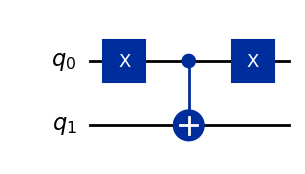

In [42]:
# ALL ORACLES IN ONE PLOT

sim = AerSimulator()

def test_oracle(oracle, name):
    for input_value in [0, 1]:
        qc = QuantumCircuit(2, 2)

        # Set input qubit if x = 1
        if input_value == 1:
            qc.x(0)

        qc.compose(oracle, inplace=True)
        qc.measure([0, 1], [0, 1])

        compiled = transpile(qc, sim)
        result = sim.run(compiled).result()

        counts = result.get_counts()
        print(f"{name}, input={input_value}: {counts}")

# Test all oracles
test_oracle(oracle_f0, "f(x)=0")
test_oracle(oracle_f1, "f(x)=1")
test_oracle(oracle_fx, "f(x)=x")
test_oracle(oracle_notx, "f(x)=¬x")

oracle_f0.draw("mpl")
oracle_f1.draw("mpl")
oracle_fx.draw("mpl")
oracle_notx.draw("mpl")

In [43]:
# Test all oracles with Deutsch's algorithm
simulator = AerSimulator()

oracle_map = {
    "Oracle 1: f(x) = 0 (constant)": oracle_f0,
    "Oracle 2: f(x) = 1 (constant)": oracle_f1 ,
    "Oracle 3: f(x) = x (balanced)": oracle_fx,
    "Oracle 4: f(x) = ¬x (balanced)": oracle_notx,
}

results = {}

for name, oracle in oracle_map.items():
    circuit = deutsch_algorithm_circuit(oracle)
    result = simulator.run(circuit, shots=1024).result()
    counts = result.get_counts()
    
    results[name] = counts
    
    print(name)
    print(counts)
    print("-" * 40)

Oracle 1: f(x) = 0 (constant)
{'0': 1024}
----------------------------------------
Oracle 2: f(x) = 1 (constant)
{'0': 1024}
----------------------------------------
Oracle 3: f(x) = x (balanced)
{'1': 1024}
----------------------------------------
Oracle 4: f(x) = ¬x (balanced)
{'1': 1024}
----------------------------------------


Oracle 1: f(x) = 0 (constant): {'0': 1024}
Oracle 2: f(x) = 1 (constant): {'0': 1024}
Oracle 3: f(x) = x (balanced): {'1': 1024}
Oracle 4: f(x) = ¬x (balanced): {'1': 1024}


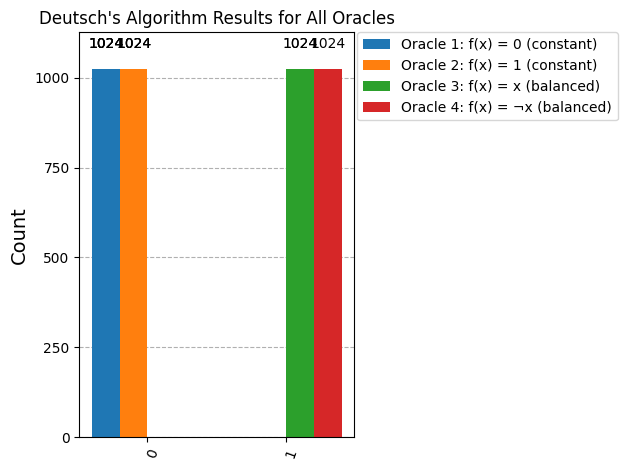

In [44]:
# plot histogram for all of the oracles

# Print counts for each oracle
for oracle_name, oracle_counts in results.items():
    print(f"{oracle_name}: {oracle_counts}")

# Visualize all oracle results in one histogram
fig = plot_histogram(
    list(results.values()),
    legend=list(results.keys()),
    title="Deutsch's Algorithm Results for All Oracles"
)
fig.savefig("img/problem4_deutsch_histogram.png", dpi=300, bbox_inches="tight")
fig

### Why One Query Is Enough

Classically, determining whether a function is constant or balanced requires checking more than one input in the worst case.

Deutsch’s algorithm avoids this by placing the input qubit into a superposition of both possible input states at once.  
The oracle then changes the relative phase of these states depending on the function.

The final Hadamard gate converts this phase information into a measurable difference:

- constant functions produce constructive interference for `0`
- balanced functions produce destructive interference for `0`, leaving `1`

As a result, the circuit determines the function type using only one application of the oracle.

---

<a id="ref-problem-4"></a>
### Problem 4 : References
- [The Deutsch Algorithm Diagram - Research Gate](https://www.researchgate.net/figure/The-Deutsch-Algorithm_fig2_342979428)
- [Deutsch's Algorithm: An Introduction to Quantum Computing Oracles](https://youtu.be/7MdEHsRZxvo?si=3QVWmm_a8ySX3na1)
- [IBM Quantum : *Deutsch's Algorithm*.](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm)

[Back to Top](#top)

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm

In this problem, Deutsch's idea is extended from one input bit to four input bits.

We are promised that the function is either:
- constant (all outputs are the same), or
- balanced (exactly half 0 and half 1).

For 4 bits there are $2^4 = 16$ inputs. A classical method may need many evaluations, but Deutsch-Jozsa determines the type with one oracle query.

### How a Classical Function Is Encoded as a Quantum Oracle

A classical function is:
$$
f(x_0,x_1,x_2,x_3) \in \{0,1\}
$$

In a quantum circuit we encode it as:
$$
|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle
$$

- $|x\rangle$ is the 4-qubit input register.
- $|y\rangle$ is one auxiliary/output qubit.
- The input register is unchanged.
- The output qubit flips only when $f(x)=1$.

To build a general oracle from any classical 4-bit function, we iterate over all 16 inputs. For each input where $f(x)=1$, we apply a multi-controlled X on the output qubit conditioned on that bit pattern.

### Reuse from Earlier Problems

To keep the notebook cleaner, Problem 5 reuses the same shared circuit pattern introduced in Problem 4:
- prepare output qubit in $|1\rangle$
- apply Hadamard gates
- apply oracle once
- apply Hadamards to input qubits
- measure input qubits

So the reader only needs to understand one circuit template (`build_deutsch_family_circuit`) used by both Deutsch and Deutsch-Jozsa.

### What We Demonstrate

We test the algorithm on:
- both constant functions (`f(x)=0`, `f(x)=1`)
- two balanced functions (first-bit function and parity function)

Decision rule:
- measured `0000` => constant
- any other output => balanced

### Problem 5 Code: Define Classical 4-Bit Functions

We use four classical functions:

- Constant: `f(x)=0`
- Constant: `f(x)=1`
- Balanced: `f(x)=x0`
- Balanced: `f(x)=x0 \oplus x1 \oplus x2 \oplus x3` (parity)

These satisfy the problem requirement: both constant functions and two balanced functions.

In [45]:
# Classical 4-bit functions (x is a tuple of 4 bits)
def f_constant_zero(x):
    return 0


def f_constant_one(x):
    return 1


def f_balanced_x0(x):
    return x[0]


def f_balanced_parity(x):
    return x[0] ^ x[1] ^ x[2] ^ x[3]


classical_functions = {
    "constant_zero": f_constant_zero,
    "constant_one": f_constant_one,
    "balanced_x0": f_balanced_x0,
    "balanced_parity": f_balanced_parity,
}

In [46]:
def build_oracle_from_classical(f, n=4):
    """
    Build an (n+1)-qubit oracle for a classical function f:{0,1}^n -> {0,1}.
    Oracle action: |x>|y> -> |x>|y XOR f(x)>
    """
    oracle = QuantumCircuit(n + 1, name=f"U_f_{f.__name__}")

    # For every input x with f(x)=1, apply a multi-controlled X on the output qubit.
    for x in product([0, 1], repeat=n):
        if f(x) == 1:
            # Turn |x> into the all-ones control pattern.
            for i, bit in enumerate(x):
                if bit == 0:
                    oracle.x(i)

            oracle.mcx(list(range(n)), n)

            # Undo temporary X gates.
            for i, bit in enumerate(x):
                if bit == 0:
                    oracle.x(i)

    return oracle


def deutsch_jozsa_circuit(oracle, n=4):
    """Compatibility wrapper for Problem 5 (4 input qubits)."""
    return build_deutsch_family_circuit(oracle, n_inputs=n)

In [47]:
n = 4
shots = 1024
simulator = AerSimulator()

results = []
all_counts = {}

for name, f in classical_functions.items():
    oracle = build_oracle_from_classical(f, n=n)
    circuit = deutsch_jozsa_circuit(oracle, n=n)

    compiled = transpile(circuit, simulator)
    counts = simulator.run(compiled, shots=shots).result().get_counts()
    all_counts[name] = counts

    measured_state = max(counts, key=counts.get)
    predicted_type = "constant" if measured_state == "0" * n else "balanced"

    if "constant" in name:
        expected_type = "constant"
    else:
        expected_type = "balanced"

    results.append(
        {
            "function": name,
            "counts": counts,
            "predicted_type": predicted_type,
            "expected_type": expected_type,
            "correct": predicted_type == expected_type,
        }
    )

results_df = pd.DataFrame(results)
results_df

,function,counts,predicted_type,expected_type,correct
0,constant_zero,{'0000': 1024},constant,constant,True
1,constant_one,{'0000': 1024},constant,constant,True
2,balanced_x0,{'0001': 1024},balanced,balanced,True
3,balanced_parity,{'1111': 1024},balanced,balanced,True


constant_zero: predicted=constant, expected=constant, correct=True, counts={'0000': 1024}
constant_one: predicted=constant, expected=constant, correct=True, counts={'0000': 1024}
balanced_x0: predicted=balanced, expected=balanced, correct=True, counts={'0001': 1024}
balanced_parity: predicted=balanced, expected=balanced, correct=True, counts={'1111': 1024}


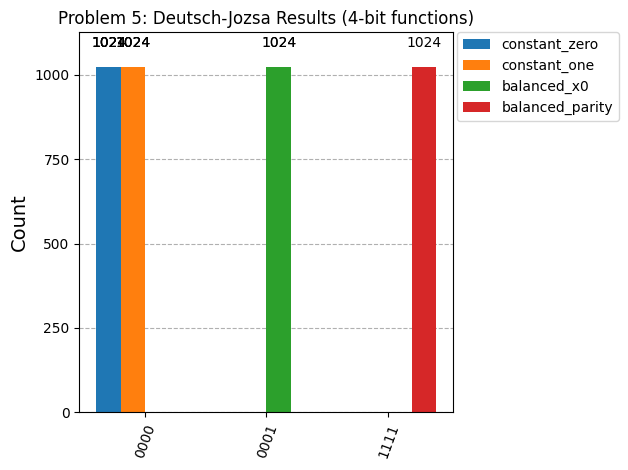

In [48]:
# Show clear text output
for row in results:
    print(
        f"{row['function']}: predicted={row['predicted_type']}, "
        f"expected={row['expected_type']}, correct={row['correct']}, counts={row['counts']}"
    )

# Visual comparison of all function runs
fig = plot_histogram(
    list(all_counts.values()),
    legend=list(all_counts.keys()),
    title="Problem 5: Deutsch-Jozsa Results (4-bit functions)",
)
fig.savefig("img/problem5_deutsch_jozsa_histogram.png", dpi=300, bbox_inches="tight")
fig

### Interpretation and Final Check

- Constant functions are identified by the all-zero measurement on input qubits (`0000`).
- Balanced functions are identified by any non-zero measurement outcome.

The output table and printed checks show that the algorithm correctly classifies:
- `f_constant_zero` and `f_constant_one` as constant
- `f_balanced_x0` and `f_balanced_parity` as balanced

So Problem 5 is fully satisfied: the oracle encoding is explained, both constant functions and two balanced functions are demonstrated, and the circuit correctly identifies function type.

<a id="ref-problem-5"></a>
### Problem 5 References
- [IBM Quantum Learning: Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
- [Qiskit Documentation: QuantumCircuit](https://qiskit.org/documentation/stubs/qiskit.circuit.QuantumCircuit.html)
- [Qiskit Textbook (archived): Deutsch-Jozsa Algorithm](https://qiskit.org/textbook/ch-algorithms/deutsch-jozsa.html)

[Back to Top](#top)